# Fault Severity Prediction — Hierarchical 1D-CNN

**Pipeline overview:**
1. Re-run data loading + preprocessing from the original notebook
2. Derive 3 severity levels (Low / Medium / High) per fault class using RMS energy + K-Means
3. Train **Model 1** — Fault Type Classifier (5 classes, FFT-domain 1D-CNN)
4. Train **Model 2** — Severity Classifier (3 levels, conditioned on predicted fault type)
5. Evaluate both models and run the full hierarchical inference pipeline

---
## Phase 1 — Data Loading & Preprocessing
*(Identical to original notebook — run this first)*

In [15]:
import zipfile, os, json, glob
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split


data_dir    = "C://Users/manimegalai/Documents/MMS_Scripts/RB2B/Balanced"
jsonl_files = glob.glob(os.path.join(data_dir, "*.jsonl"))
all_data    = []

for file_path in jsonl_files:
    filename = os.path.basename(file_path)
    state    = filename.split('_3000')[0].replace('_', ' ')
    with open(file_path, 'r') as f:
        for line in f:
            try:
                row = json.loads(line.strip())
                row['machine_state'] = state
                all_data.append(row)
            except json.JSONDecodeError:
                continue

df = pd.DataFrame(all_data)
print(f"Rows loaded: {len(df)}")
display(df.head())

Rows loaded: 14877


,time,axis,data,machine_state
0,1.776822e+09,Z,"[299.6708984375, 277.6708984375, 280.670898437...",Bearing
1,1.776822e+09,X,"[-193.755859375, -251.755859375, -274.75585937...",Bearing
2,1.776822e+09,Y,"[-57.8876953125, 29.1123046875, 42.1123046875,...",Bearing
3,1.776822e+09,Z,"[644.228515625, 606.228515625, 606.228515625, ...",Bearing
4,1.776822e+09,X,"[-220.9033203125, -225.9033203125, -254.903320...",Bearing


In [16]:
# ── 3. Synchronise X/Y/Z triplets ─────────────────────────────────────────────
merged_records = []

for state, group_df in df.groupby('machine_state'):
    group_df   = group_df.sort_values('time')
    buffer     = {}
    expected   = 'X'
    group_time = None

    for _, row in group_df.iterrows():
        axis = row['axis']
        wave = row['data']
        t    = row['time']

        if axis == 'X' and expected == 'X':
            buffer = {'X': wave};  group_time = t;  expected = 'Y'
        elif axis == 'Y' and expected == 'Y':
            buffer['Y'] = wave;  expected = 'Z'
        elif axis == 'Z' and expected == 'Z':
            buffer['Z'] = wave
            merged_records.append({'time': group_time, 'machine_state': state,
                                   'X': buffer['X'], 'Y': buffer['Y'], 'Z': buffer['Z']})
            buffer = {};  expected = 'X'
        else:
            buffer = ({'X': wave, } if axis == 'X' else {})
            group_time = t if axis == 'X' else None
            expected   = 'Y' if axis == 'X' else 'X'

df_merged = pd.DataFrame(merged_records)
print(f"Merged triplets: {len(df_merged)}")
display(df_merged.head())

Merged triplets: 3776


,time,machine_state,X,Y,Z
0,1.776822e+09,Bearing,"[-193.755859375, -251.755859375, -274.75585937...","[-57.8876953125, 29.1123046875, 42.1123046875,...","[644.228515625, 606.228515625, 606.228515625, ..."
1,1.776822e+09,Bearing,"[-220.9033203125, -225.9033203125, -254.903320...","[-225.3955078125, -124.3955078125, -48.3955078...","[724.76953125, 583.76953125, 324.76953125, 61...."
2,1.776822e+09,Bearing,"[-413.71875, -349.71875, -232.71875, -164.7187...","[-114.404296875, -53.404296875, 7.595703125, 2...","[-73.88671875, 390.11328125, 550.11328125, 509..."
3,1.776822e+09,Bearing,"[192.1318359375, 139.1318359375, 205.131835937...","[467.4365234375, 464.4365234375, 437.436523437...","[508.0029296875, 439.0029296875, 249.002929687..."
4,1.776822e+09,Bearing,"[-234.951171875, -19.951171875, 141.048828125,...","[-241.10546875, -309.10546875, -370.10546875, ...","[214.82421875, 101.82421875, -30.17578125, -15..."


In [17]:
print(df_merged['machine_state'].value_counts())
# ── Downsample to minimum class count ────────────────────────────────────────
# TARGET = df_merged['machine_state'].value_counts().min()
# print(f"Target samples per class: {TARGET}")

# balanced_dfs = []
# for state, group in df_merged.groupby('machine_state'):
#     sampled = group.sample(n=TARGET, random_state=42)
#     balanced_dfs.append(sampled)

# df_merged = pd.concat(balanced_dfs).sample(frac=1, random_state=42).reset_index(drop=True)

# print(f"\nAfter balancing:")
# print(df_merged['machine_state'].value_counts())
# print(f"\nTotal samples: {len(df_merged)}")

machine_state
Bearing         1163
Misalignment     766
Normal           696
Unbalanced       597
Mechanical       554
Name: count, dtype: int64


In [18]:
# ── 4. Build tensors & normalise ──────────────────────────────────────────────
X_data = np.array(df_merged['X'].tolist())
Y_data = np.array(df_merged['Y'].tolist())
Z_data = np.array(df_merged['Z'].tolist())

tensors = np.stack((X_data, Y_data, Z_data), axis=1)   # (N, 3, 1024)
labels  = df_merged['machine_state'].values

samples, channels, seq_len = tensors.shape

scaler          = StandardScaler()
reshaped        = tensors.transpose(0, 2, 1).reshape(-1, channels)
scaled          = scaler.fit_transform(reshaped)
tensors_norm    = scaled.reshape(samples, seq_len, channels).transpose(0, 2, 1)  # (N,3,1024)

print(f"Normalised tensor shape: {tensors_norm.shape}")

Normalised tensor shape: (3776, 3, 1024)


In [19]:
# ── Keras format: transpose to (N, 1024, 3) ───────────────────────────────────
tensors_keras = np.transpose(tensors_norm, (0, 2, 1))  # (N, 1024, 3)

# ── FFT transform ─────────────────────────────────────────────────────────────
tensors_fft = np.abs(np.fft.rfft(tensors_keras, axis=1))  # (N, 513, 3)
tensors_fft = np.log1p(tensors_fft)

print(f"FFT tensor shape: {tensors_fft.shape}")

# ── Encode fault-type labels ───────────────────────────────────────────────────
fault_encoder   = LabelEncoder()
fault_labels    = fault_encoder.fit_transform(labels)         # 0–4

print("\nFault label mapping:")
for i, name in enumerate(fault_encoder.classes_):
    print(f"  {i} → {name}")

FFT tensor shape: (3776, 513, 3)

Fault label mapping:
  0 → Bearing
  1 → Mechanical
  2 → Misalignment
  3 → Normal
  4 → Unbalanced


In [20]:
idx = np.arange(len(tensors_fft))

idx_train, idx_temp = train_test_split(idx, test_size=0.30,
                                        random_state=42, stratify=fault_labels)
idx_val, idx_test   = train_test_split(idx_temp, test_size=0.50,
                                        random_state=42, stratify=fault_labels[idx_temp])

X_train = tensors_fft[idx_train];  X_val = tensors_fft[idx_val];  X_test = tensors_fft[idx_test]
y_fault_train = fault_labels[idx_train]
y_fault_val   = fault_labels[idx_val]
y_fault_test  = fault_labels[idx_test]

print(f"Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}")

Train: (2643, 513, 3)  Val: (566, 513, 3)  Test: (567, 513, 3)


Unique fault labels: 5
Classes: ['Bearing' 'Mechanical' 'Misalignment' 'Normal' 'Unbalanced']


C:\Users\manimegalai\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "fault_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)                    │ (None, 513, 64)             │           1,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 513, 64)             │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_6 (Activation)            │ (None, 513, 64)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_6 (MaxPooling1D)       │ (None, 256, 64)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_7 (Conv1D)                    │ (None, 256, 128)            │          41,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ (None, 256, 128)            │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_7 (Activation)            │ (None, 256, 128)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_7 (MaxPooling1D)       │ (None, 128, 128)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_8 (Conv1D)                    │ (None, 128, 256)            │          98,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 128, 256)            │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_8 (Activation)            │ (None, 128, 256)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_8 (MaxPooling1D)       │ (None, 64, 256)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d_2           │ (None, 256)                 │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 176,389 (689.02 KB)

 Trainable params: 175,493 (685.52 KB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 12s 84ms/step - accuracy: 0.4113 - loss: 1.4270 - val_accuracy: 0.1855 - val_loss: 1.5906 - learning_rate: 1.0000e-04
Epoch 2/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 7s 80ms/step - accuracy: 0.5206 - loss: 1.2105 - val_accuracy: 0.4205 - val_loss: 1.5623 - learning_rate: 1.0000e-04
Epoch 3/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 7s 80ms/step - accuracy: 0.5709 - loss: 1.0896 - val_accuracy: 0.5212 - val_loss: 1.5112 - learning_rate: 1.0000e-04
Epoch 4/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 7s 78ms/step - accuracy: 0.6561 - loss: 0.9751 - val_accuracy: 0.3357 - val_loss: 1.4522 - learning_rate: 1.0000e-04
Epoch 5/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step - accuracy: 0.7007 - loss: 0.8931 - val_accuracy: 0.3710 - val_loss: 1.4278 - learning_rate: 1.0000e-04
Epoch 6/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 6s 70ms/step - accuracy: 0.7514 - loss: 0.8137 - val_accuracy: 0.2809 - val_loss: 1.4295 - learning_rate: 1.0000e-04
Epoch 7/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step - accuracy:

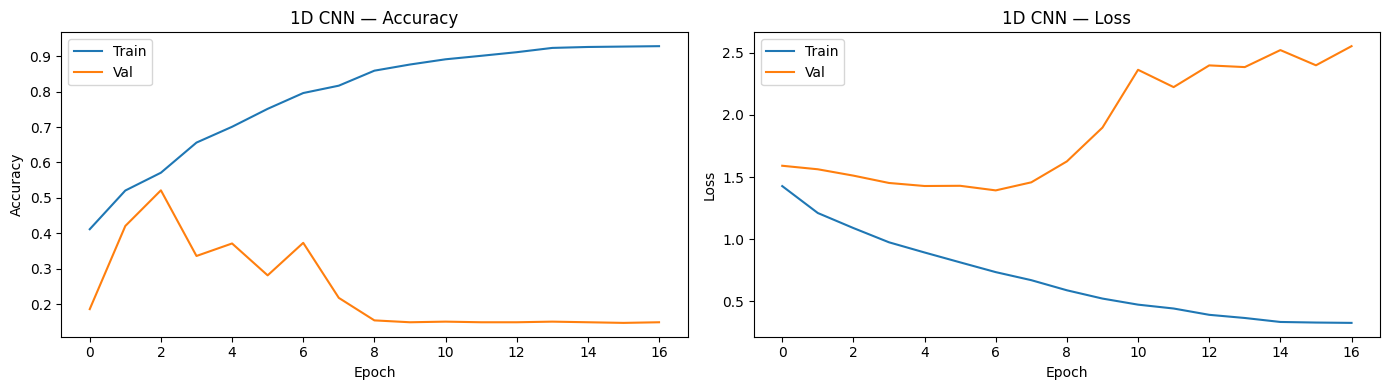


1D CNN — Test Accuracy: 0.3721
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step 

Classification Report:
              precision    recall  f1-score   support

     Bearing       0.67      0.01      0.02       175
  Mechanical       0.22      1.00      0.36        83
Misalignment       0.00      0.00      0.00       115
      Normal       0.67      0.92      0.78       105
  Unbalanced       0.78      0.33      0.46        89

    accuracy                           0.37       567
   macro avg       0.47      0.45      0.32       567
weighted avg       0.49      0.37      0.28       567



C:\Users\manimegalai\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\manimegalai\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\manimegalai\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

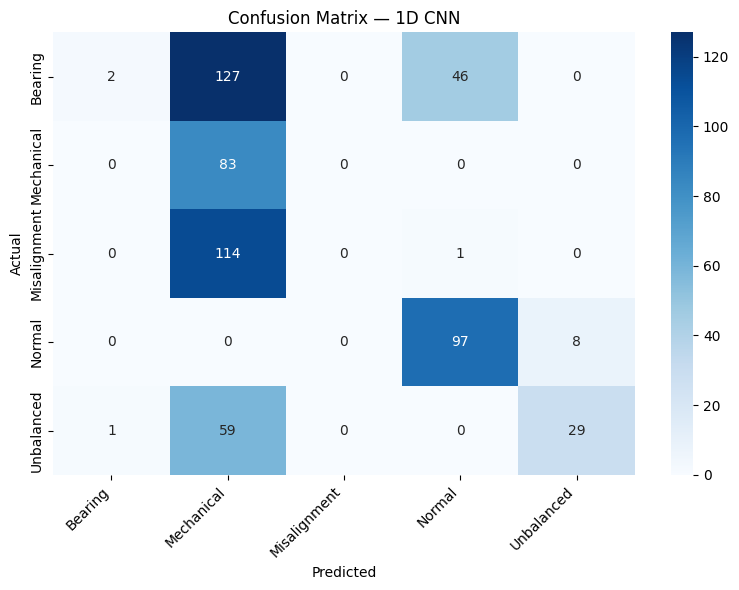

In [21]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv1D, MaxPooling1D, GlobalAveragePooling1D,
                                      Dense, Dropout, BatchNormalization, Activation)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

freq_bins = X_train.shape[1]   # 513
n_ch      = X_train.shape[2]   # 3

def build_fault_model(freq_bins, n_channels, n_classes):
    model = Sequential([
        Conv1D(64,  7, padding='same', input_shape=(freq_bins, n_channels)),
        BatchNormalization(), Activation('relu'), MaxPooling1D(2),

        Conv1D(128, 5, padding='same'),
        BatchNormalization(), Activation('relu'), MaxPooling1D(2),

        Conv1D(256, 3, padding='same'),
        BatchNormalization(), Activation('relu'), MaxPooling1D(2),

        GlobalAveragePooling1D(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(n_classes, activation='softmax')
    ], name='fault_classifier')
    return model

# ── Build & Compile ──────────────────────────────────────────────────────────
print("Unique fault labels:", len(fault_encoder.classes_))
print("Classes:", fault_encoder.classes_)

n_classes = len(fault_encoder.classes_)
model = build_fault_model(freq_bins, n_ch, n_classes)

model.compile(
    optimizer=Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

# ── Train ────────────────────────────────────────────────────────────────────
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
]

history = model.fit(
    X_train, y_fault_train,
    validation_data=(X_val, y_fault_val),
    epochs=100,
    batch_size=32,
    callbacks=callbacks
)

# ── Plot ─────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(history.history['accuracy'],     label='Train')
ax1.plot(history.history['val_accuracy'], label='Val')
ax1.set_title('1D CNN — Accuracy')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy'); ax1.legend()

ax2.plot(history.history['loss'],     label='Train')
ax2.plot(history.history['val_loss'], label='Val')
ax2.set_title('1D CNN — Loss')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss'); ax2.legend()

plt.tight_layout()
plt.show()

# ── Evaluate ──────────────────────────────────────────────────────────────────
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

_, test_acc = model.evaluate(X_test, y_fault_test, verbose=0)
print(f"\n1D CNN — Test Accuracy: {test_acc:.4f}")

y_pred = np.argmax(model.predict(X_test), axis=1)
print("\nClassification Report:")
print(classification_report(y_fault_test, y_pred, target_names=fault_encoder.classes_))

cm = confusion_matrix(y_fault_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=fault_encoder.classes_,
            yticklabels=fault_encoder.classes_)
plt.title('Confusion Matrix — 1D CNN')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

MiniRocket input shape: (3776, 3, 1024)
Train: (2643, 3, 1024) | Val: (566, 3, 1024) | Test: (567, 3, 1024)

Training MiniRocket...
Training complete.

Val  Accuracy : 1.0000
Test Accuracy : 1.0000

Classification Report:
              precision    recall  f1-score   support

     Bearing       1.00      1.00      1.00       175
  Mechanical       1.00      1.00      1.00        83
Misalignment       1.00      1.00      1.00       115
      Normal       1.00      1.00      1.00       105
  Unbalanced       1.00      1.00      1.00        89

    accuracy                           1.00       567
   macro avg       1.00      1.00      1.00       567
weighted avg       1.00      1.00      1.00       567



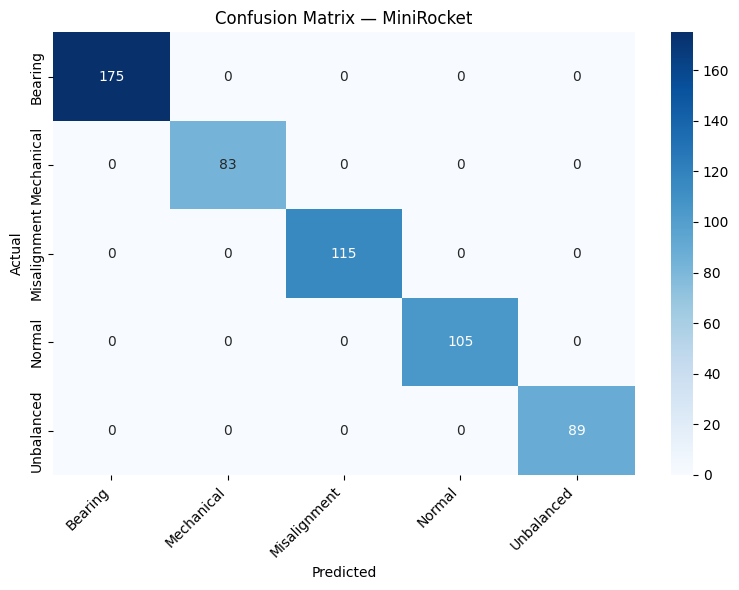

In [22]:
from aeon.classification.convolution_based import MiniRocketClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ── Data Prep ─────────────────────────────────────────────────────────────────
# MiniRocket needs raw waveforms NOT FFT, shape must be (N, channels, timesteps)
X_rocket = tensors_keras.transpose(0, 2, 1)   # (1668, 3, 1024)

print(f"MiniRocket input shape: {X_rocket.shape}")  # confirm (N, 3, 1024)

X_r_train = X_rocket[idx_train]
X_r_val   = X_rocket[idx_val]
X_r_test  = X_rocket[idx_test]

print(f"Train: {X_r_train.shape} | Val: {X_r_val.shape} | Test: {X_r_test.shape}")

# ── Build & Train ─────────────────────────────────────────────────────────────
rocket_model = MiniRocketClassifier(
    n_kernels=10000,
    n_jobs=-1             # uses all CPU cores
)

print("\nTraining MiniRocket...")
rocket_model.fit(X_r_train, y_fault_train)
print("Training complete.")

# ── Evaluate ──────────────────────────────────────────────────────────────────
val_acc  = rocket_model.score(X_r_val,  y_fault_val)
test_acc = rocket_model.score(X_r_test, y_fault_test)

print(f"\nVal  Accuracy : {val_acc:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")

# ── Classification Report ─────────────────────────────────────────────────────
y_pred = rocket_model.predict(X_r_test)

print("\nClassification Report:")
print(classification_report(y_fault_test, y_pred,
                             target_names=fault_encoder.classes_))

# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_fault_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=fault_encoder.classes_,
            yticklabels=fault_encoder.classes_)
plt.title('Confusion Matrix — MiniRocket')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Model: "MultiScale_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)    │ (None, 513, 3)            │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_22 (Conv1D)            │ (None, 513, 64)           │             640 │ input_layer_4[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_24 (Conv1D)            │ (None, 513, 64)           │           1,408 │ input_layer_4[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_26 (Conv1D)            │ (None, 513, 64)           │           2,944 │ input_layer_4[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_28 (Conv1D)            │ (None, 513, 64)           │           6,016 │ input_layer_4[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_22        │ (None, 513, 64)           │             256 │ conv1d_22[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_24        │ (None, 513, 64)           │             256 │ conv1d_24[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_26        │ (None, 513, 64)           │             256 │ conv1d_26[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_28        │ (None, 513, 64)           │             256 │ conv1d_28[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_22 (Activation)    │ (None, 513, 64)           │               0 │ batch_normalization_22[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_24 (Activation)    │ (None, 513, 64)           │               0 │ batch_normalization_24[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_26 (Activation)    │ (None, 513, 64)           │               0 │ batch_normalization_26[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_28 (Activation)    │ (None, 513, 64)           │               0 │ batch_normalization_28[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_23 (Conv1D)            │ (None, 513, 64)           │          12,352 │ activation_22[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_25 (Conv1D)            │ (None, 513, 64)           │          28,736 │ activation_24[0][0]        │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 606,085 (2.31 MB)

 Trainable params: 604,293 (2.31 MB)

 Non-trainable params: 1,792 (7.00 KB)

Epoch 1/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 102s 808ms/step - accuracy: 0.4438 - loss: 1.3153 - val_accuracy: 0.1537 - val_loss: 1.6973 - learning_rate: 3.0000e-04
Epoch 2/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 65s 784ms/step - accuracy: 0.6784 - loss: 0.8630 - val_accuracy: 0.1466 - val_loss: 3.2954 - learning_rate: 3.0000e-04
Epoch 3/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 67s 802ms/step - accuracy: 0.8282 - loss: 0.5689 - val_accuracy: 0.1502 - val_loss: 5.0202 - learning_rate: 3.0000e-04
Epoch 4/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 52s 624ms/step - accuracy: 0.8907 - loss: 0.3924 - val_accuracy: 0.1466 - val_loss: 4.6799 - learning_rate: 3.0000e-04
Epoch 5/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 56s 682ms/step - accuracy: 0.9190 - loss: 0.2831 - val_accuracy: 0.1519 - val_loss: 5.9170 - learning_rate: 3.0000e-04
Epoch 6/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 67s 801ms/step - accuracy: 0.9364 - loss: 0.2306 - val_accuracy: 0.1820 - val_loss: 3.3618 - learning_rate: 3.0000e-04
Epoch 7/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 60s 727ms/st

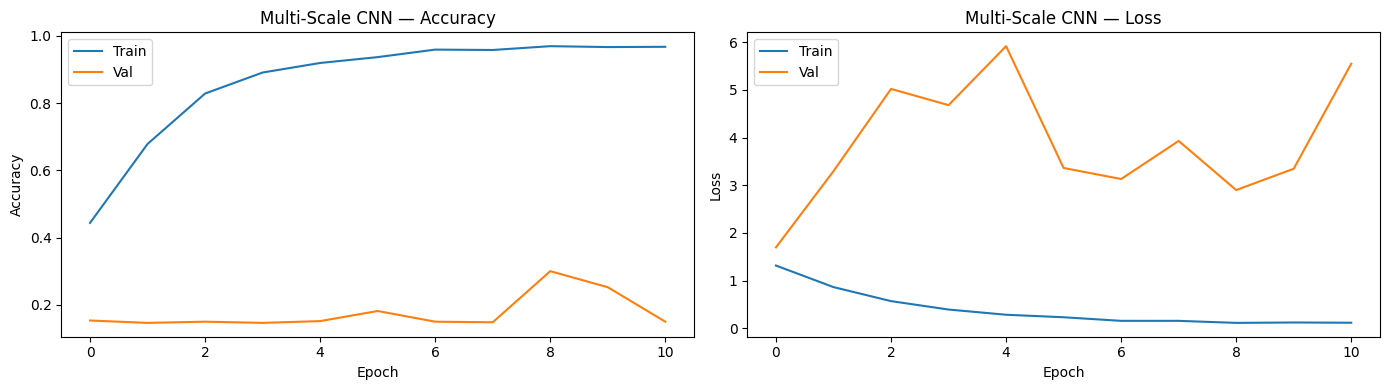


Multi-Scale CNN — Test Accuracy: 0.1481
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 109ms/step

Classification Report:
              precision    recall  f1-score   support

     Bearing       0.00      0.00      0.00       175
  Mechanical       0.15      1.00      0.26        83
Misalignment       0.00      0.00      0.00       115
      Normal       0.20      0.01      0.02       105
  Unbalanced       0.00      0.00      0.00        89

    accuracy                           0.15       567
   macro avg       0.07      0.20      0.06       567
weighted avg       0.06      0.15      0.04       567



C:\Users\manimegalai\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\manimegalai\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\manimegalai\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

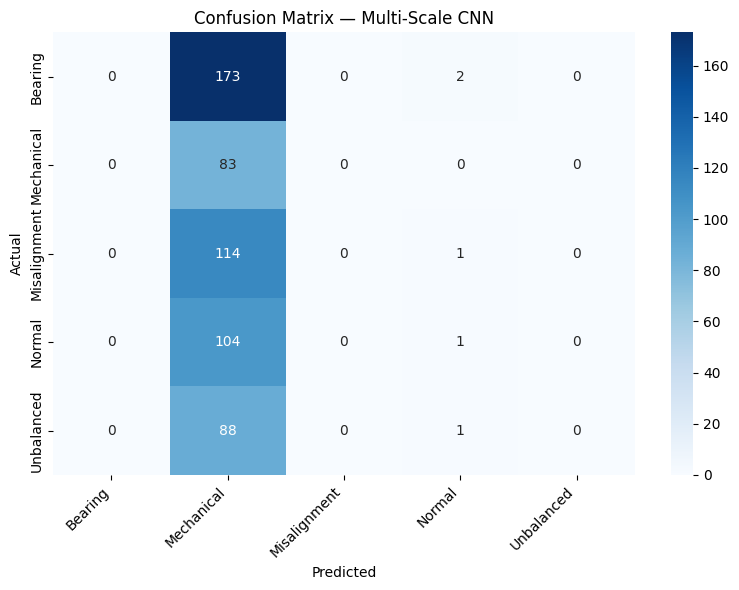

In [24]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Conv1D, MaxPooling1D, GlobalAveragePooling1D,
                                      Dense, Dropout, BatchNormalization,
                                      Activation, Input, Concatenate)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np

# ── Multi-Scale CNN ───────────────────────────────────────────────────────────
def build_multiscale_cnn(freq_bins, n_channels, n_classes):

    inputs = Input(shape=(freq_bins, n_channels))

    # ── Scale 1: Small kernel — fine-grained frequency details ────────────────
    s1 = Conv1D(64, 3, padding='same')(inputs)
    s1 = BatchNormalization()(s1); s1 = Activation('relu')(s1)
    s1 = Conv1D(64, 3, padding='same')(s1)
    s1 = BatchNormalization()(s1); s1 = Activation('relu')(s1)
    s1 = MaxPooling1D(2)(s1)

    # ── Scale 2: Medium kernel — mid-range patterns ───────────────────────────
    s2 = Conv1D(64, 7, padding='same')(inputs)
    s2 = BatchNormalization()(s2); s2 = Activation('relu')(s2)
    s2 = Conv1D(64, 7, padding='same')(s2)
    s2 = BatchNormalization()(s2); s2 = Activation('relu')(s2)
    s2 = MaxPooling1D(2)(s2)

    # ── Scale 3: Large kernel — broadband patterns ────────────────────────────
    s3 = Conv1D(64, 15, padding='same')(inputs)
    s3 = BatchNormalization()(s3); s3 = Activation('relu')(s3)
    s3 = Conv1D(64, 15, padding='same')(s3)
    s3 = BatchNormalization()(s3); s3 = Activation('relu')(s3)
    s3 = MaxPooling1D(2)(s3)

    # ── Scale 4: Very large kernel — low frequency global trends ──────────────
    s4 = Conv1D(64, 31, padding='same')(inputs)
    s4 = BatchNormalization()(s4); s4 = Activation('relu')(s4)
    s4 = Conv1D(64, 31, padding='same')(s4)
    s4 = BatchNormalization()(s4); s4 = Activation('relu')(s4)
    s4 = MaxPooling1D(2)(s4)

    # ── Merge all scales ──────────────────────────────────────────────────────
    merged = Concatenate()([s1, s2, s3, s4])          # (256, 256)

    # ── Deep feature extraction after fusion ──────────────────────────────────
    x = Conv1D(128, 5, padding='same')(merged)
    x = BatchNormalization()(x); x = Activation('relu')(x)
    x = MaxPooling1D(2)(x); x = Dropout(0.2)(x)

    x = Conv1D(256, 3, padding='same')(x)
    x = BatchNormalization()(x); x = Activation('relu')(x)
    x = MaxPooling1D(2)(x); x = Dropout(0.3)(x)

    x = GlobalAveragePooling1D()(x)

    # ── Classification head ───────────────────────────────────────────────────
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.4)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(n_classes, activation='softmax')(x)

    return Model(inputs, outputs, name='MultiScale_CNN')


# ── Build & Compile ───────────────────────────────────────────────────────────
freq_bins = X_train.shape[1]   # 513
n_ch      = X_train.shape[2]   # 3
n_classes = len(fault_encoder.classes_)

model_ms = build_multiscale_cnn(freq_bins, n_ch, n_classes)

model_ms.compile(
    optimizer=Adam(learning_rate=3e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_ms.summary()

# ── Callbacks ─────────────────────────────────────────────────────────────────
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
]

# ── Train ─────────────────────────────────────────────────────────────────────
history_ms = model_ms.fit(
    X_train, y_fault_train,
    validation_data=(X_val, y_fault_val),
    epochs=100,
    batch_size=32,
    callbacks=callbacks
)

# ── Plot ──────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(history_ms.history['accuracy'],     label='Train')
ax1.plot(history_ms.history['val_accuracy'], label='Val')
ax1.set_title('Multi-Scale CNN — Accuracy')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy'); ax1.legend()

ax2.plot(history_ms.history['loss'],     label='Train')
ax2.plot(history_ms.history['val_loss'], label='Val')
ax2.set_title('Multi-Scale CNN — Loss')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss'); ax2.legend()

plt.tight_layout()
plt.show()

# ── Evaluate ──────────────────────────────────────────────────────────────────
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

_, test_acc = model_ms.evaluate(X_test, y_fault_test, verbose=0)
print(f"\nMulti-Scale CNN — Test Accuracy: {test_acc:.4f}")

y_pred_ms = np.argmax(model_ms.predict(X_test), axis=1)

print("\nClassification Report:")
print(classification_report(y_fault_test, y_pred_ms,
                             target_names=fault_encoder.classes_))

# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_fault_test, y_pred_ms)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=fault_encoder.classes_,
            yticklabels=fault_encoder.classes_)
plt.title('Confusion Matrix — Multi-Scale CNN')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()